## Project: Predicting Loan Repayment

### 1. Motivation

Automating loan approvals can help financial institutions make faster, more consistent decisions. However, it's crucial to minimize the risk of approving loans that will not be fully repaid. In this project, we aim to build a machine learning classifier to predict whether a loan will be paid back, using historical loan data. Special attention will be given to the class imbalance (fewer "not fully paid" loans) and the higher cost of false negatives (predicting a loan will be paid back when it won't).

# Loan Data
This dataset consists of more than 9,500 loans with information on the loan structure, the borrower, and whether the loan was pain back in full. This data was extracted from LendingClub.com, which is a company that connects borrowers with investors. 

Not sure where to begin? Scroll to the bottom to find challenges!

In [3]:
import pandas as pd
loan_data = pd.read_csv("loan_data.csv")
print(loan_data.shape)
loan_data.head(100)

(9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,debt_consolidation,0.0775,156.11,10.714418,5.00,762,2131.000000,1359,5.6,2,0,0,0
96,1,debt_consolidation,0.1154,329.95,12.323856,20.00,727,10292.000000,107501,44.8,2,0,0,0
97,1,all_other,0.0807,313.67,12.061047,0.72,787,8010.000000,3054,5.6,3,0,0,0
98,1,all_other,0.0807,297.99,11.407565,2.44,792,8717.958333,40384,9.6,0,0,0,0


## Data dictionary

|    | Variable          | Explanation                                                                                                             |
|---:|:------------------|:------------------------------------------------------------------------------------------------------------------------|
|  0 | credit_policy     | 1 if the customer meets the credit underwriting criteria; 0 otherwise.                                                  |
|  1 | purpose           | The purpose of the loan.                                                                                                |
|  2 | int_rate          | The interest rate of the loan (more risky borrowers are assigned higher interest rates).                                |
|  3 | installment       | The monthly installments owed by the borrower if the loan is funded.                                                    |
|  4 | log_annual_inc    | The natural log of the self-reported annual income of the borrower.                                                     |
|  5 | dti               | The debt-to-income ratio of the borrower (amount of debt divided by annual income).                                     |
|  6 | fico              | The FICO credit score of the borrower.                                                                                  |
|  7 | days_with_cr_line | The number of days the borrower has had a credit line.                                                                  |
|  8 | revol_bal         | The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).                           |
|  9 | revol_util        | The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available). |
| 10 | inq_last_6mths    | The borrower's number of inquiries by creditors in the last 6 months.                                                   |
| 11 | delinq_2yrs       | The number of times the borrower had been 30+ days past due on a payment in the past 2 years.                           |
| 12 | pub_rec           | The borrower's number of derogatory public records.                                                                     |
| 13 | not_fully_paid    | 1 if the loan is not fully paid; 0 otherwise.   

[Source](https://www.kaggle.com/itssuru/loan-data) of dataset.

In [8]:
#### 2.2. Data Overview

# Check for missing values and data types
loan_data.info()
loan_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

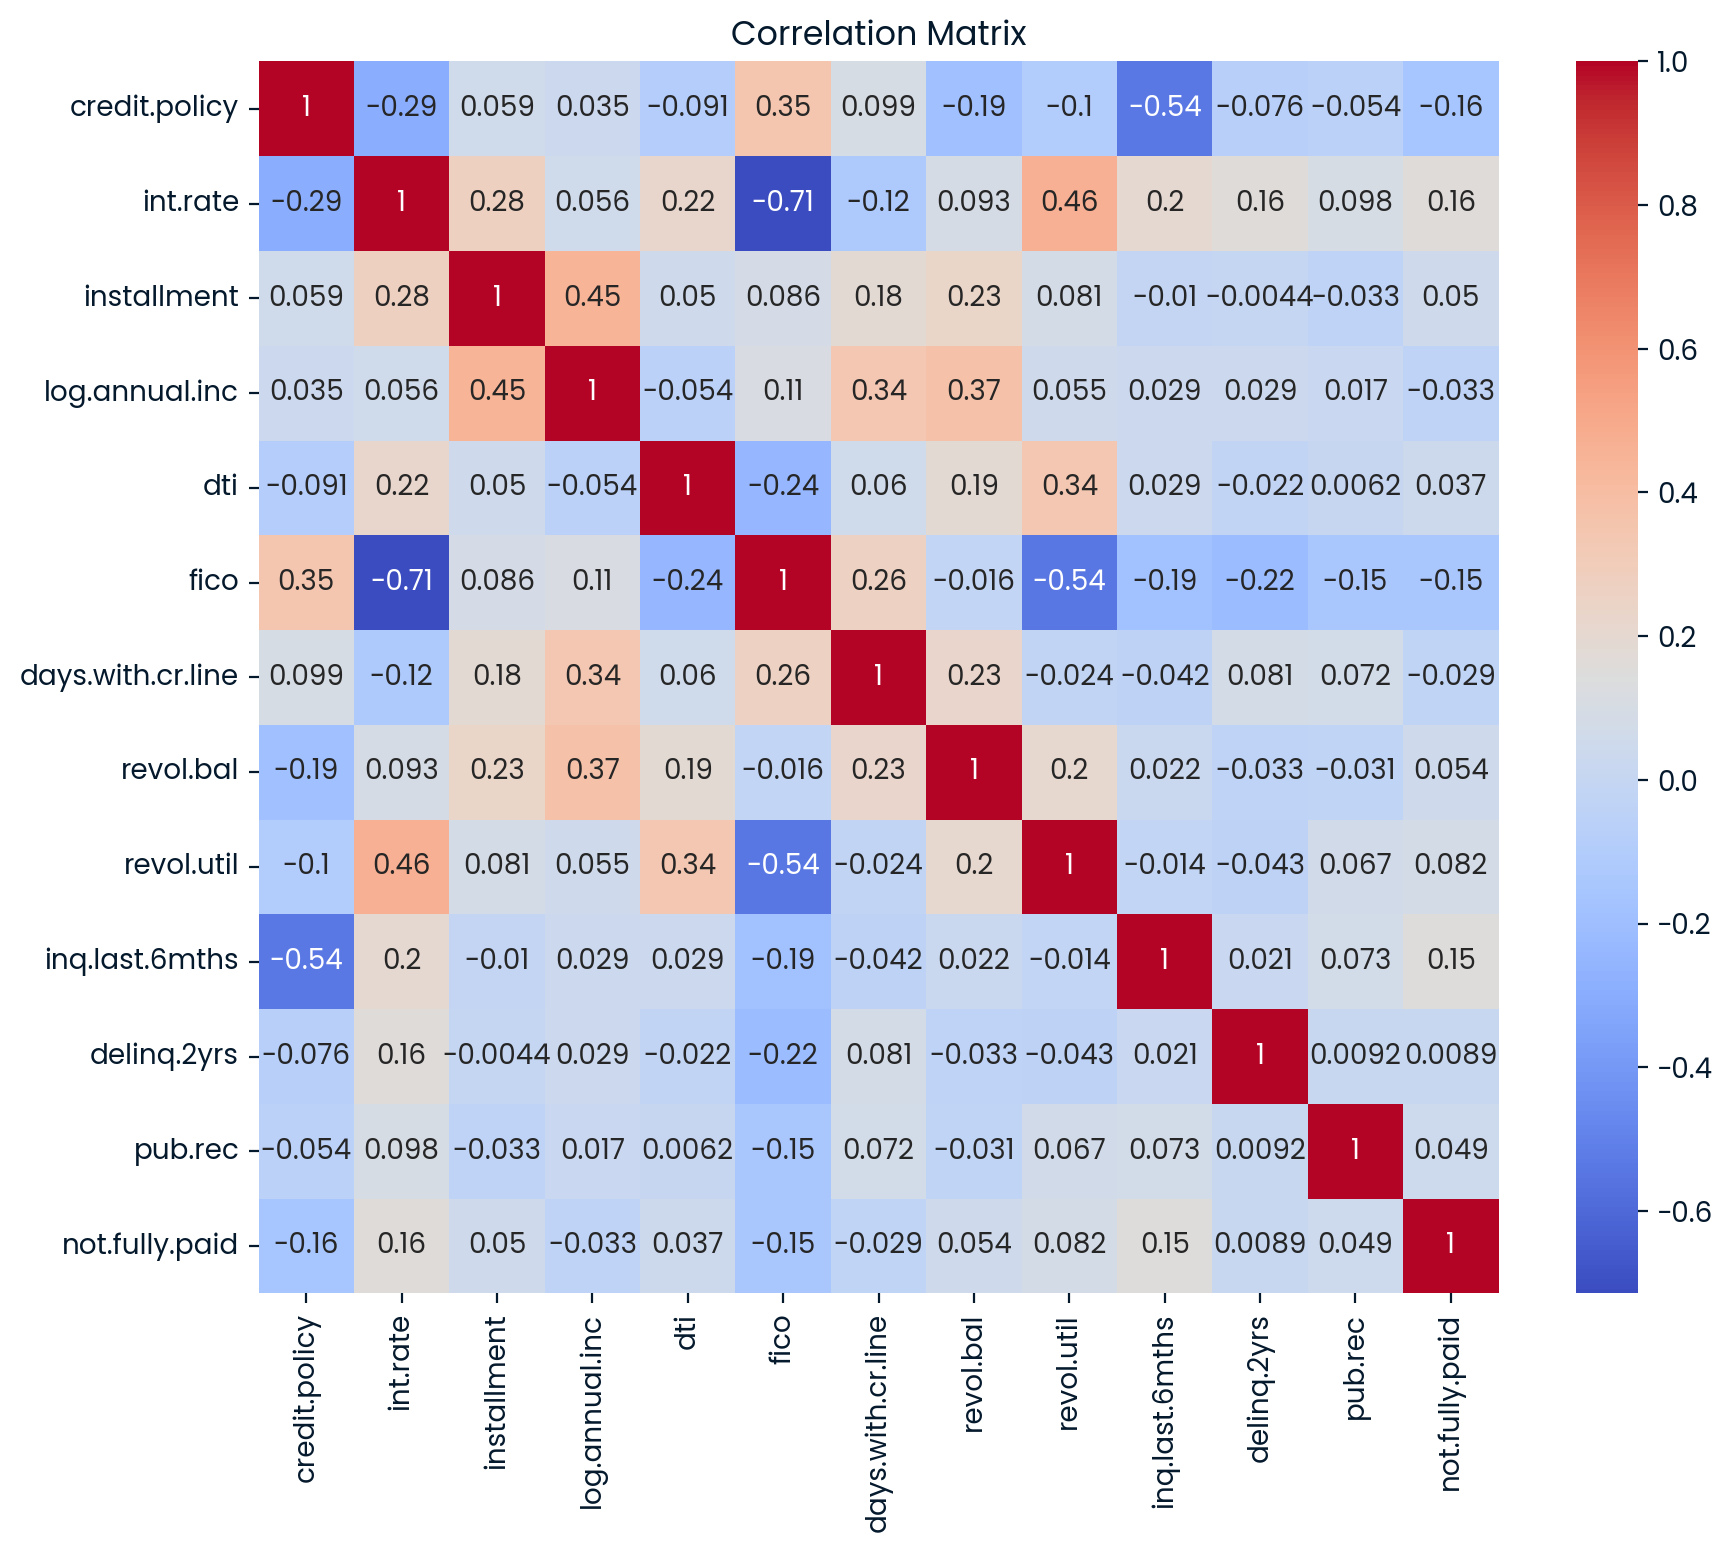

In [9]:
#### 2.3. Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numeric columns
corr = loan_data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

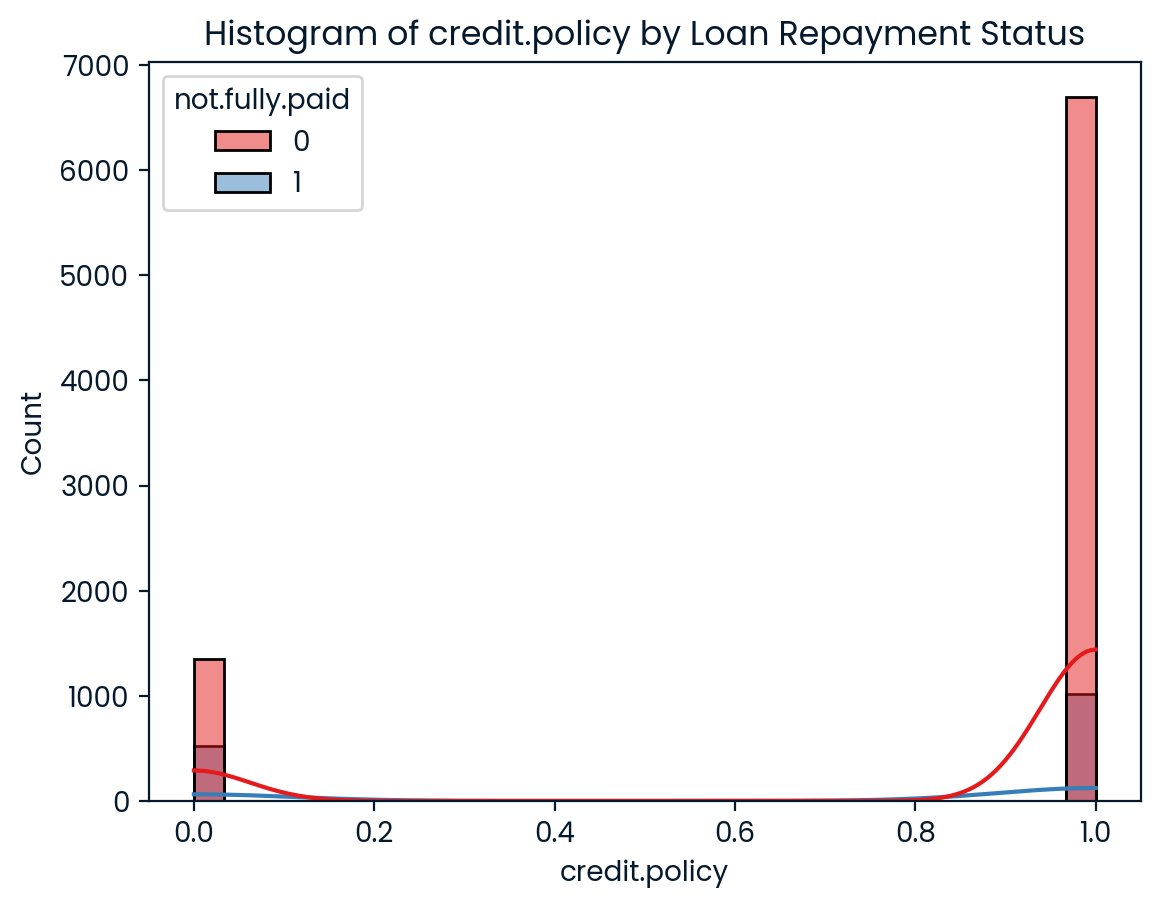

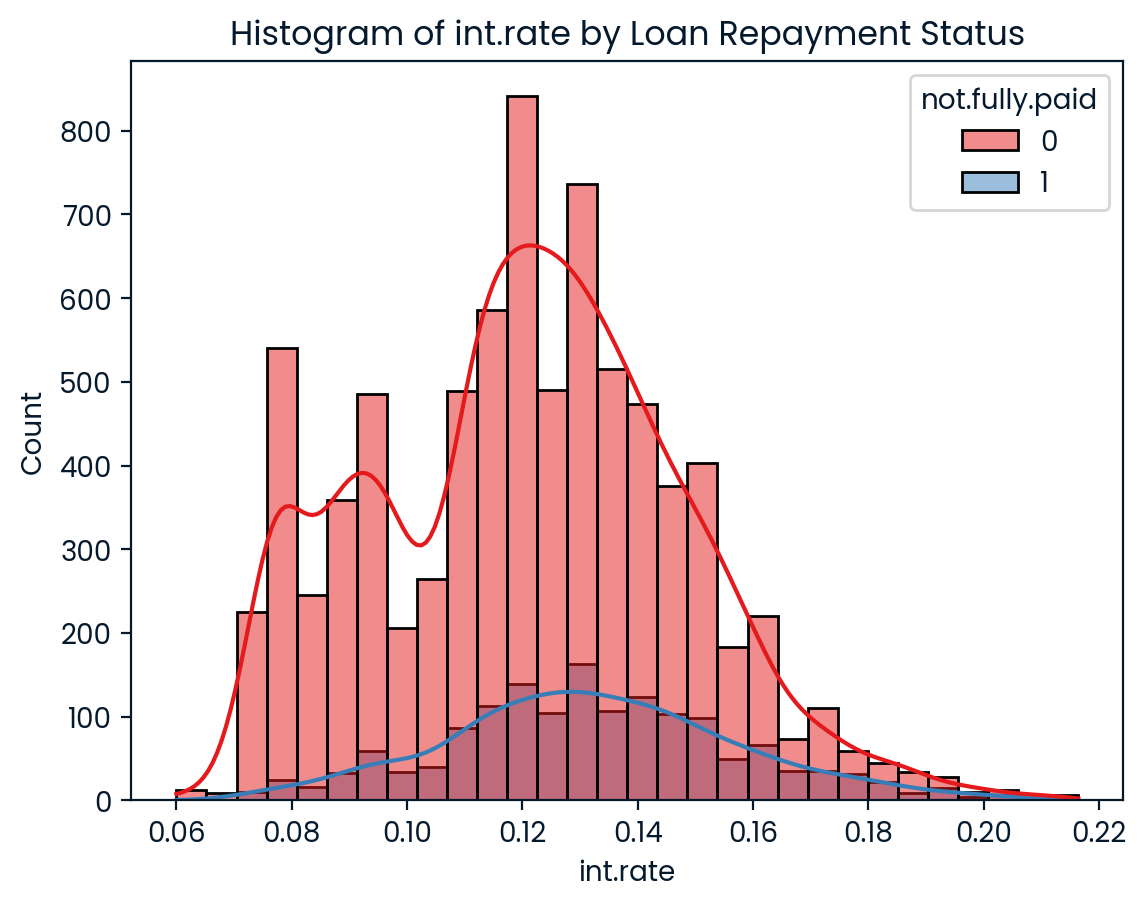

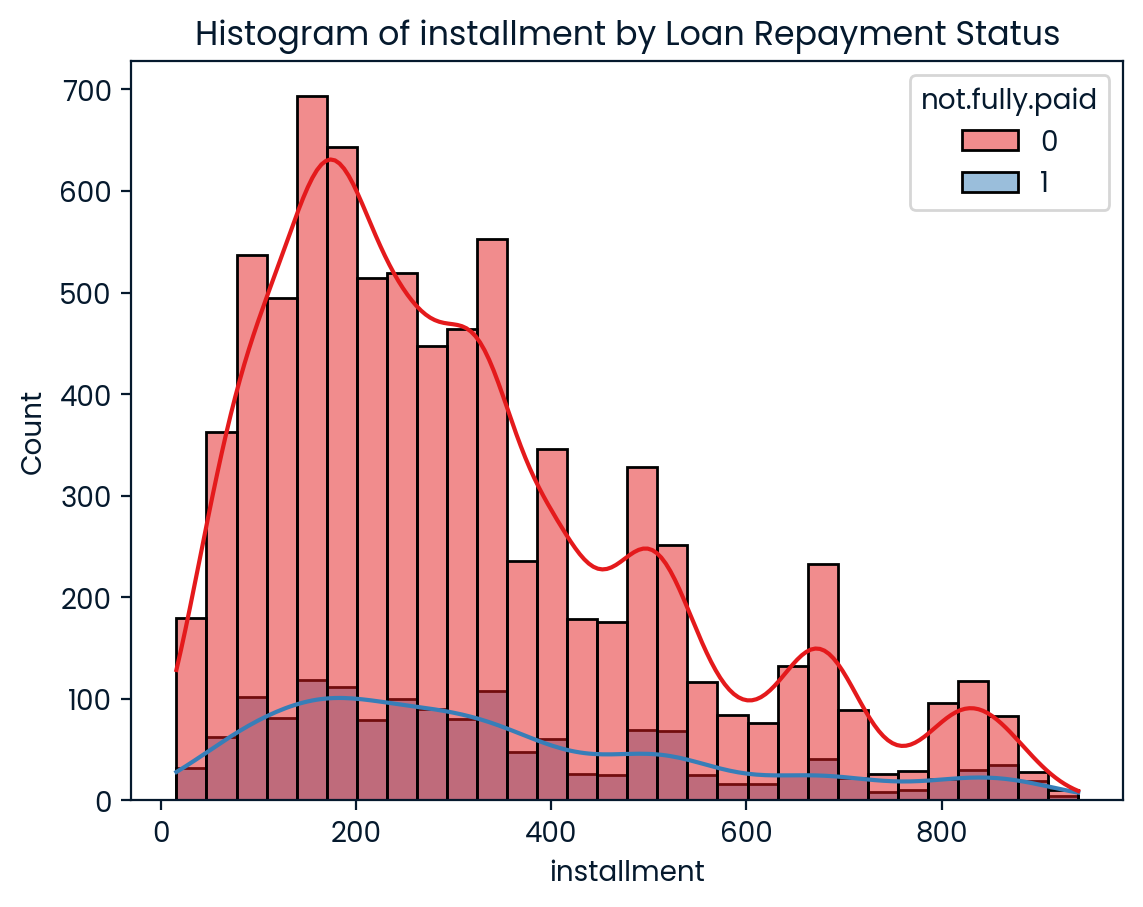

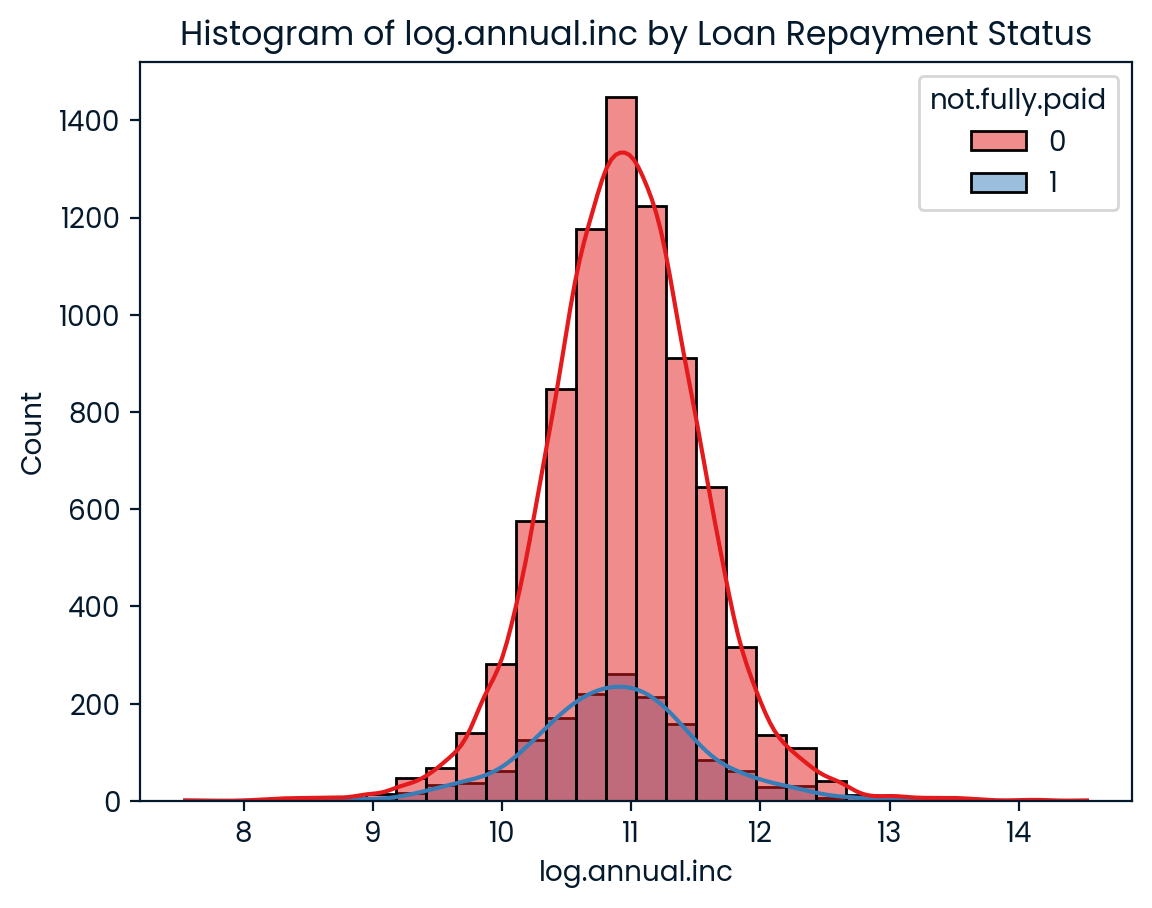

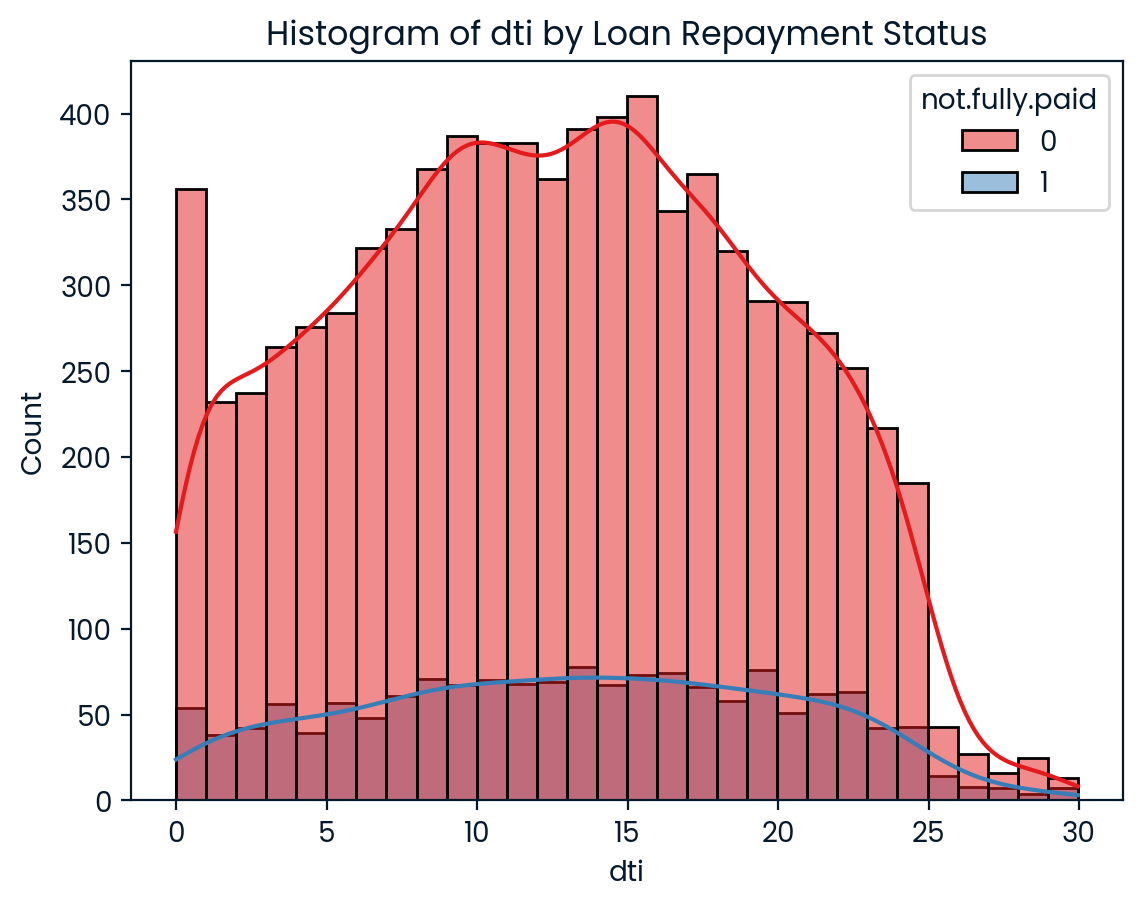

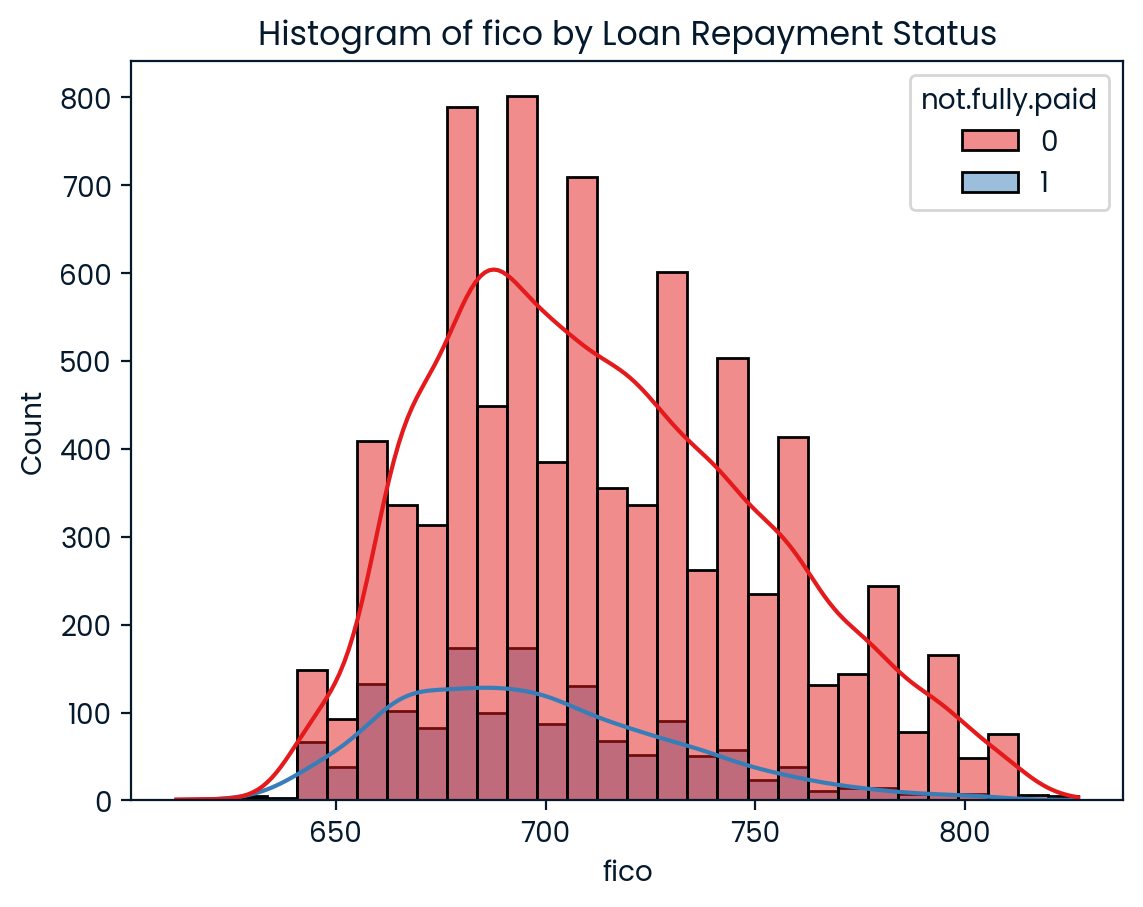

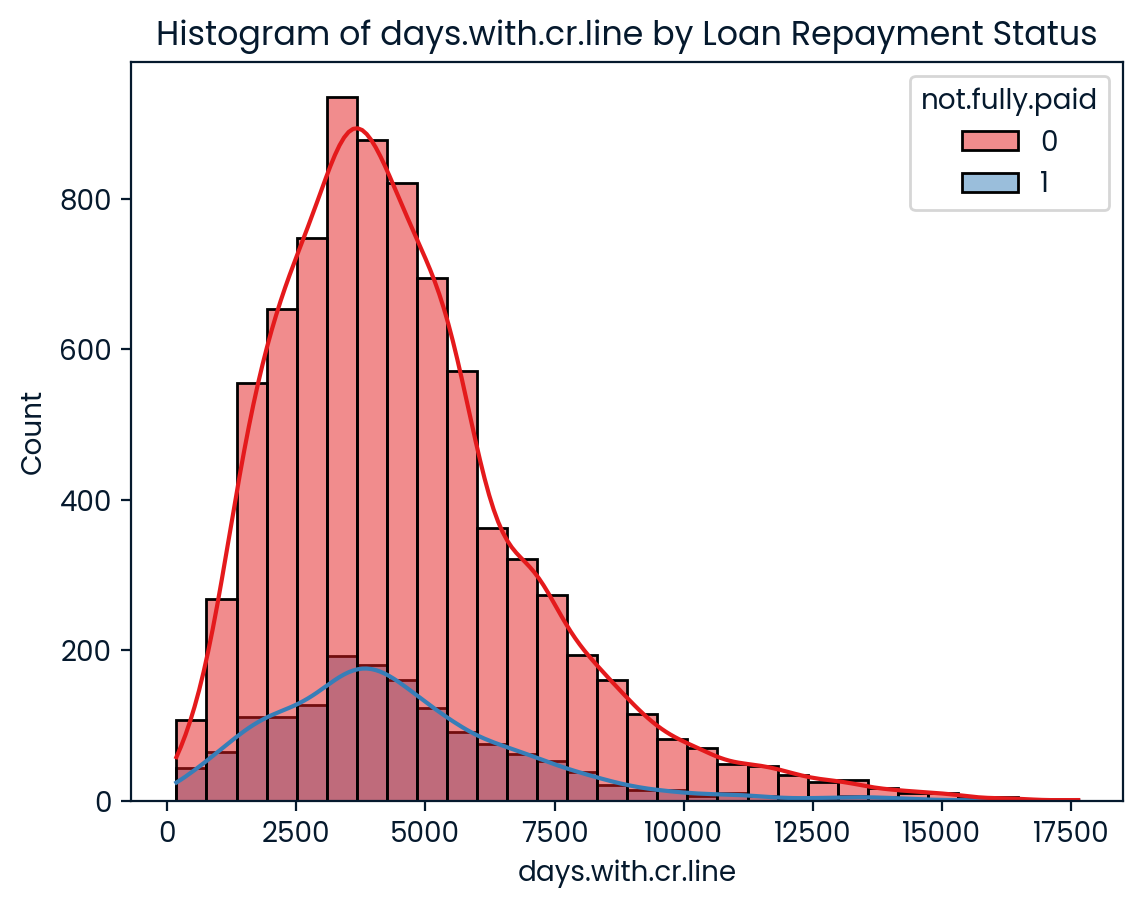

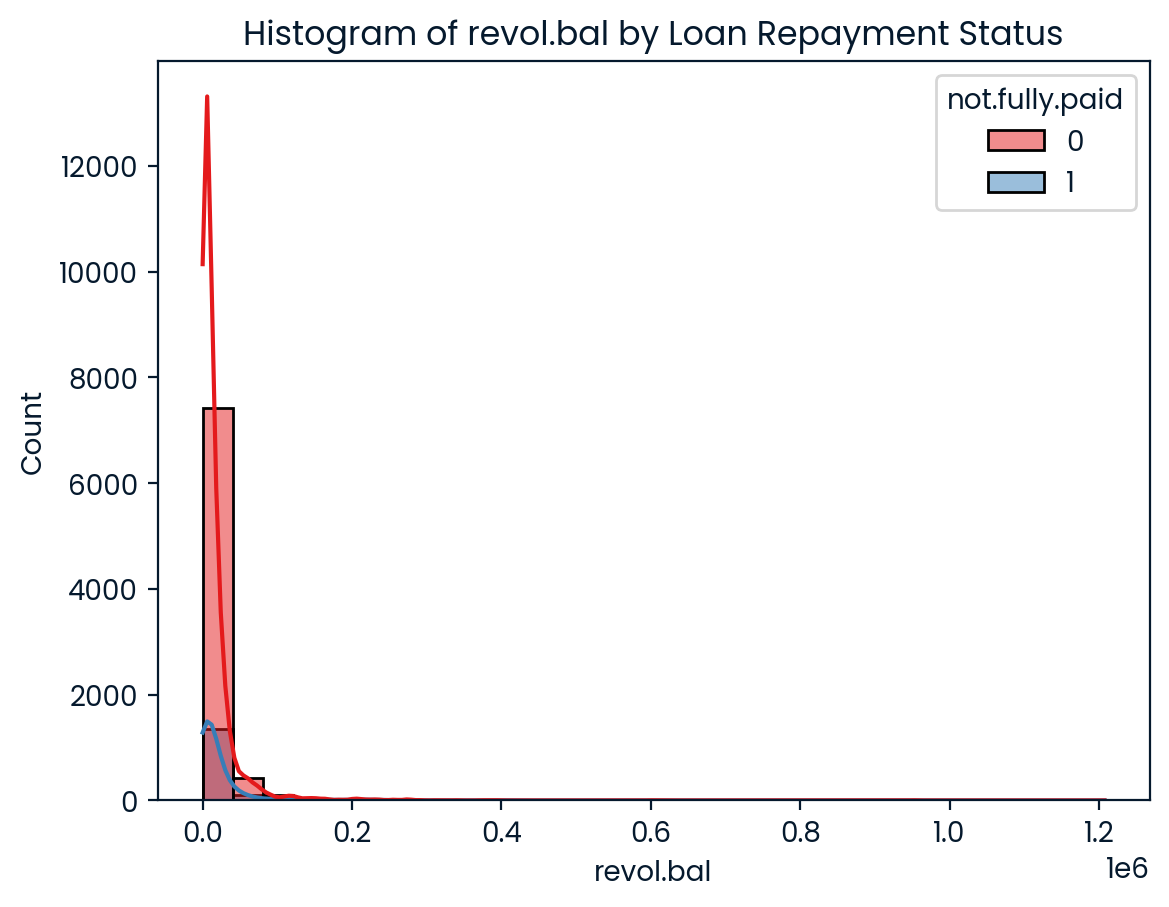

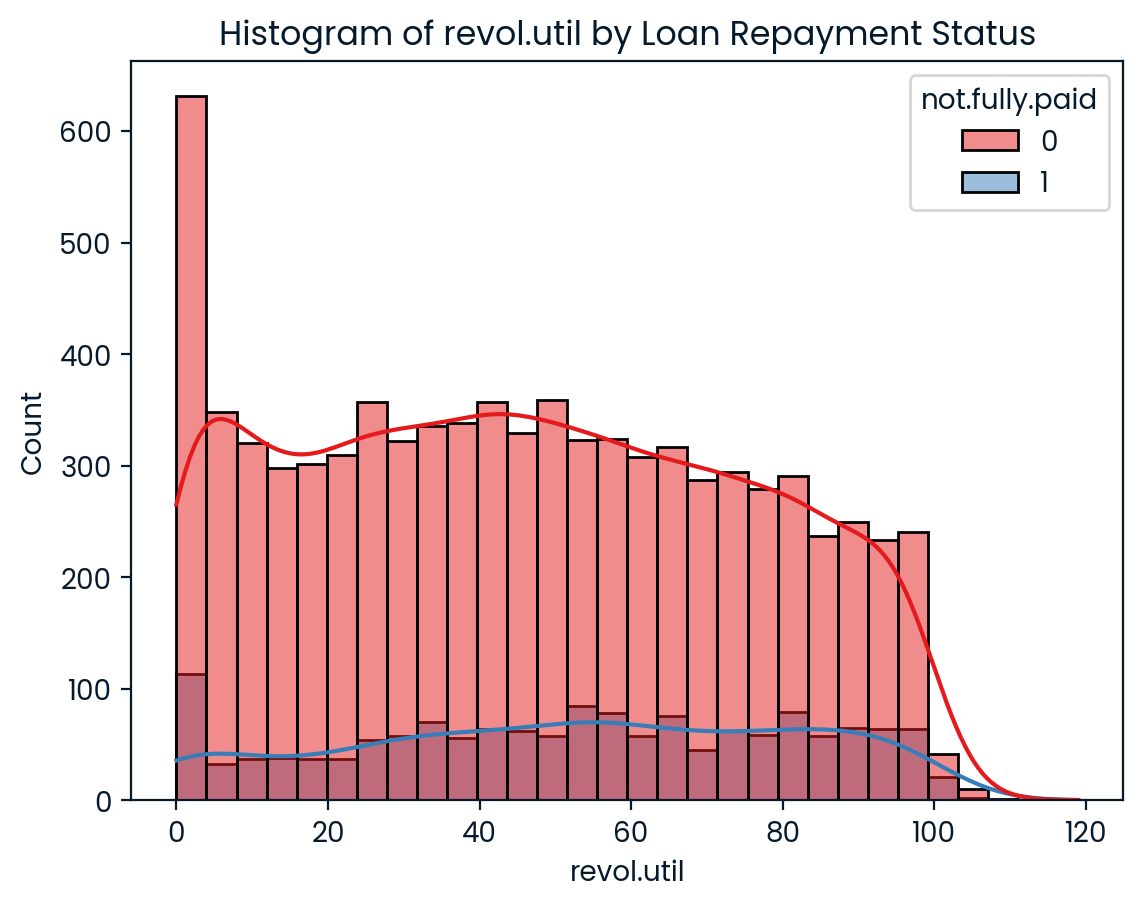

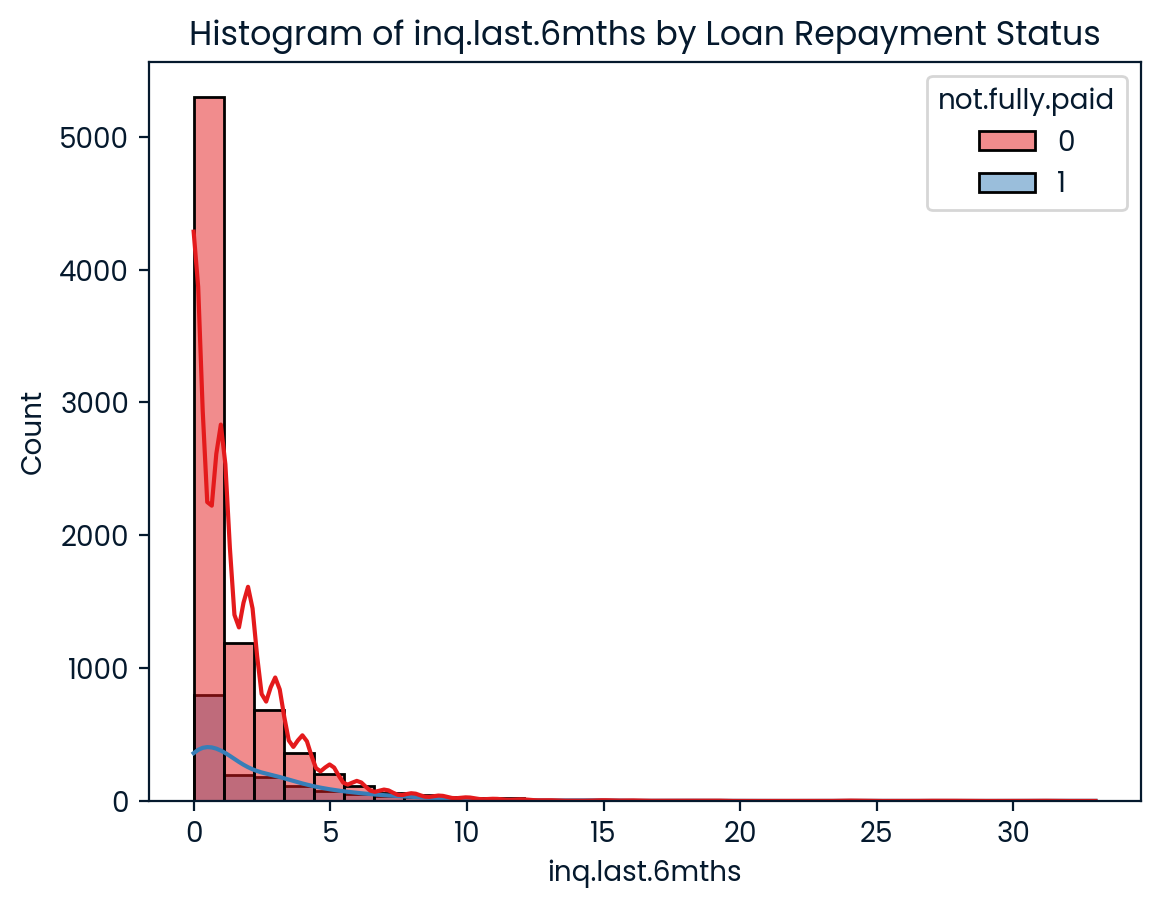

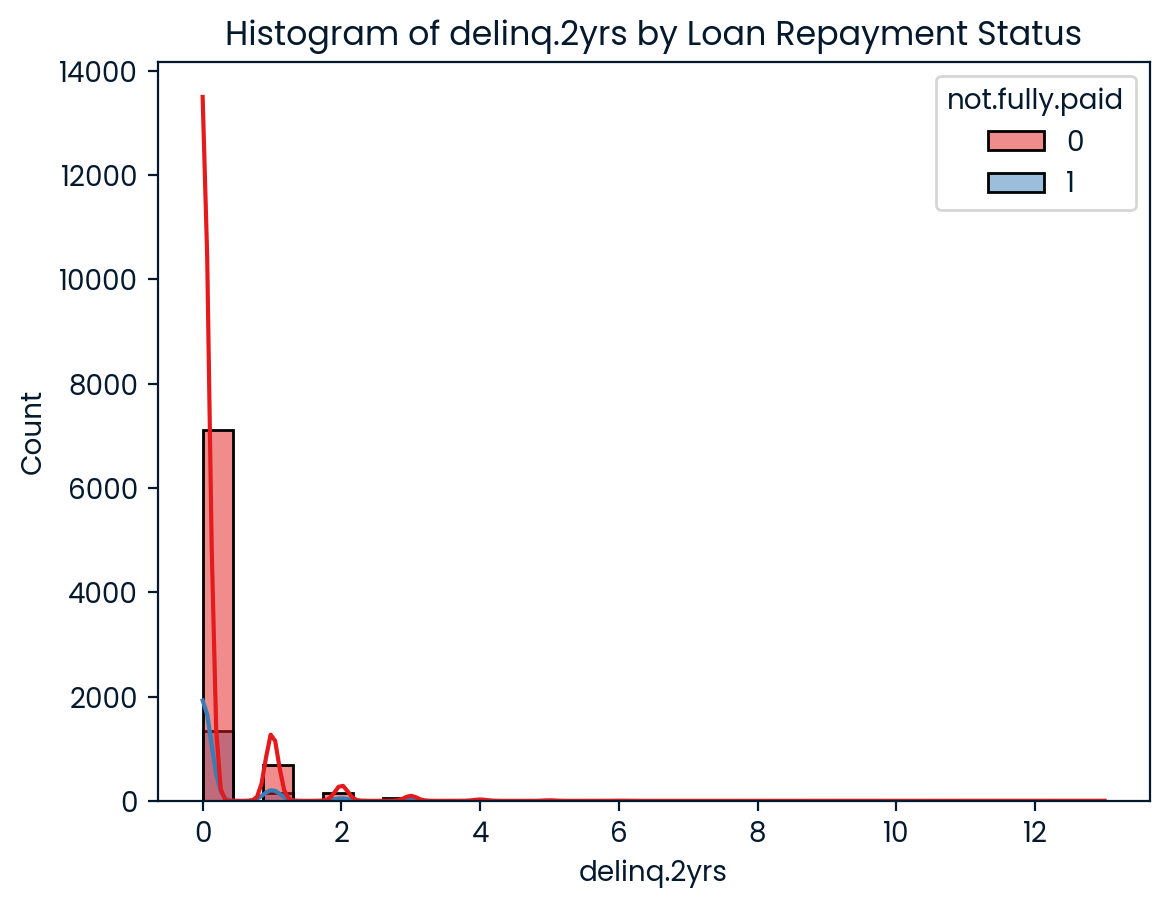

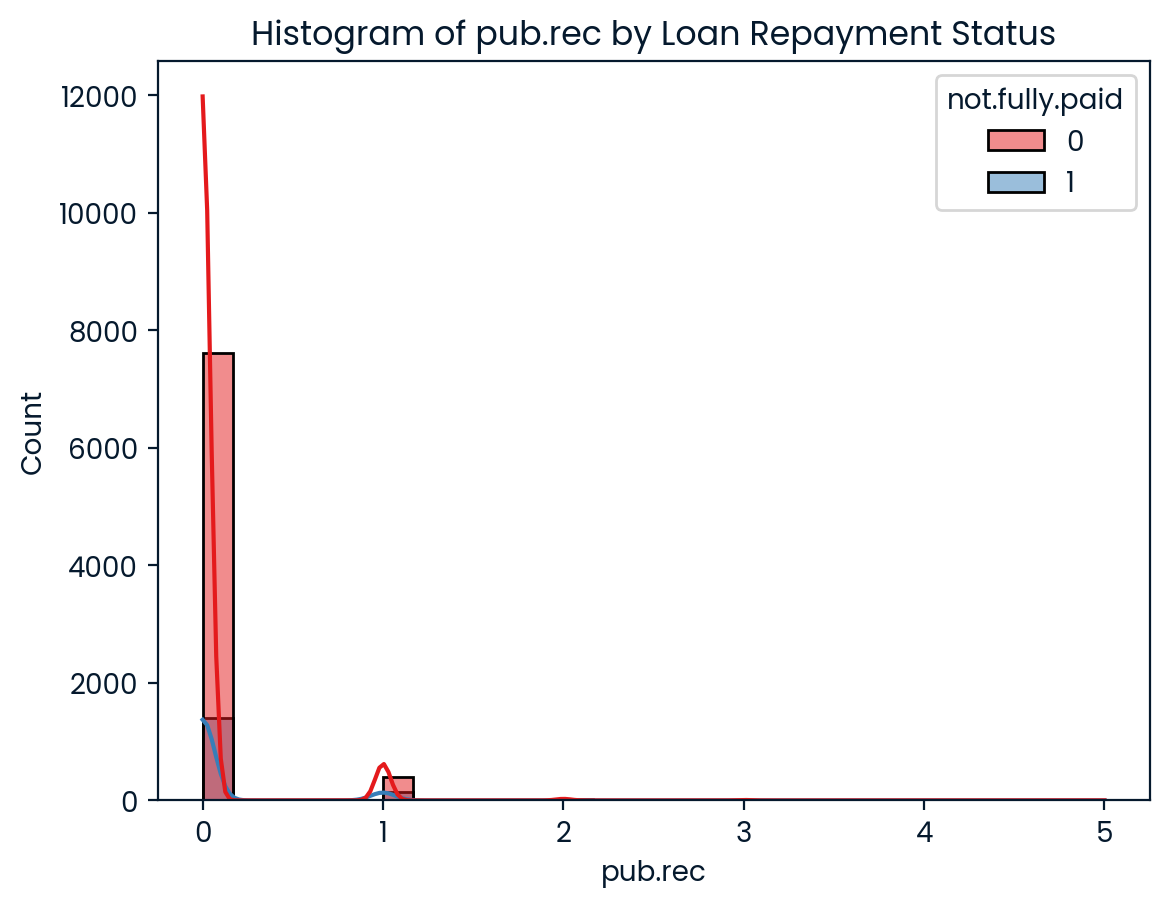

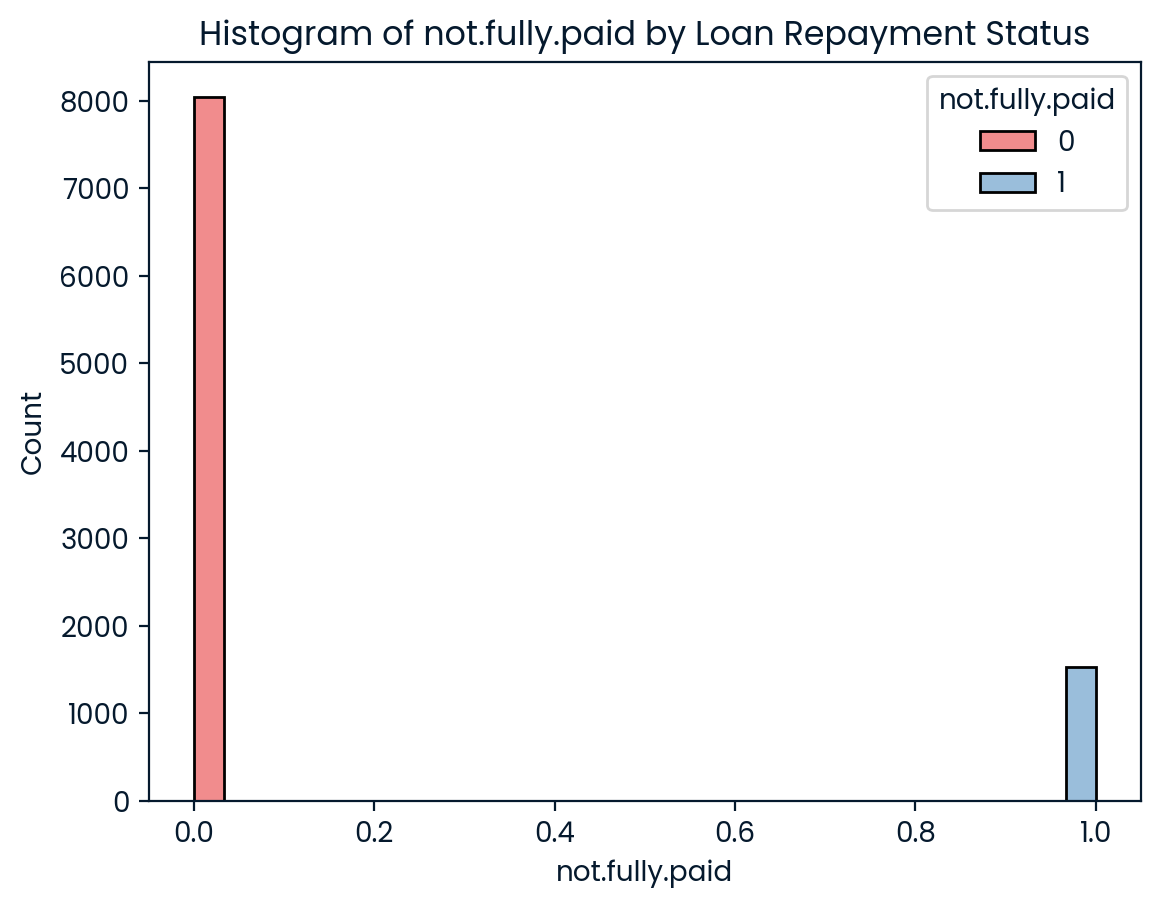

In [12]:
### 3. Data Visualization

#### 3.1. Histograms by `not.fully.paid`

numeric_cols = loan_data.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(data=loan_data, x=col, hue='not.fully.paid', bins=30, kde=True, palette='Set1')
    plt.title(f'Histogram of {col} by Loan Repayment Status')
    plt.show()

In [17]:
### 4. Data Analysis

#### 4.1. Group by Purpose

# Check the columns to find the correct column name
print(loan_data.columns)

# Analyze fully paid loans by purpose
fully_paid = loan_data[loan_data['not.fully.paid'] == 0]
grouped = fully_paid.groupby('purpose').mean(numeric_only=True)
display(grouped)

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
purpose,,,,,,,,,,,,,
all_other,0.819444,0.114679,242.789563,10.863416,10.916178,718.604938,4376.061535,11935.462963,37.895844,1.497942,0.179527,0.047325,0.0
credit_card,0.828853,0.118223,314.171111,11.048897,14.036281,711.565412,4848.749067,22687.840502,52.660932,1.284946,0.146953,0.060932,0.0
debt_consolidation,0.837507,0.125386,359.392123,10.924729,13.956565,705.947525,4557.299940,16798.795766,53.335844,1.348241,0.166070,0.063208,0.0
educational,0.773723,0.117594,210.592883,10.550979,11.137883,711.343066,4075.359945,10271.828467,37.767518,1.624088,0.145985,0.040146,0.0
home_improvement,0.856322,0.115046,327.754579,11.219836,10.015728,728.091954,5240.562500,17383.534483,32.847720,1.660920,0.134100,0.059387,0.0
major_purchase,0.858247,0.112487,229.849330,10.847106,10.132474,724.719072,4379.534901,7207.664948,32.389691,1.438144,0.170103,0.048969,0.0
small_business,0.843400,0.134806,413.373356,11.127708,10.313870,724.225951,4905.584079,22721.984340,37.464206,1.785235,0.120805,0.049217,0.0


In [19]:
### 5. Data Preprocessing

#### 5.1. Handle Missing Values

# Simple imputation for missing values
loan_data = loan_data.fillna(loan_data.median(numeric_only=True))

#### 5.2. Encode Categorical Variables

# One-hot encode 'purpose'
loan_data = pd.get_dummies(loan_data, columns=['purpose'], drop_first=True)

#### 5.3. Feature/Target Split

X = loan_data.drop('not.fully.paid', axis=1)
y = loan_data['not.fully.paid']


In [21]:
### 6. Model Building

#### 6.1. Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#### 6.2. Handle Class Imbalance

# Option 1: Use class weights in the model.
# Option 2: Use resampling (e.g., SMOTE, RandomOverSampler).

from sklearn.ensemble import RandomForestClassifier

# Use class_weight='balanced' to address imbalance
clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

[[1605    4]
 [ 304    3]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1609
           1       0.43      0.01      0.02       307

    accuracy                           0.84      1916
   macro avg       0.63      0.50      0.47      1916
weighted avg       0.77      0.84      0.77      1916

ROC-AUC: 0.6682261626882986


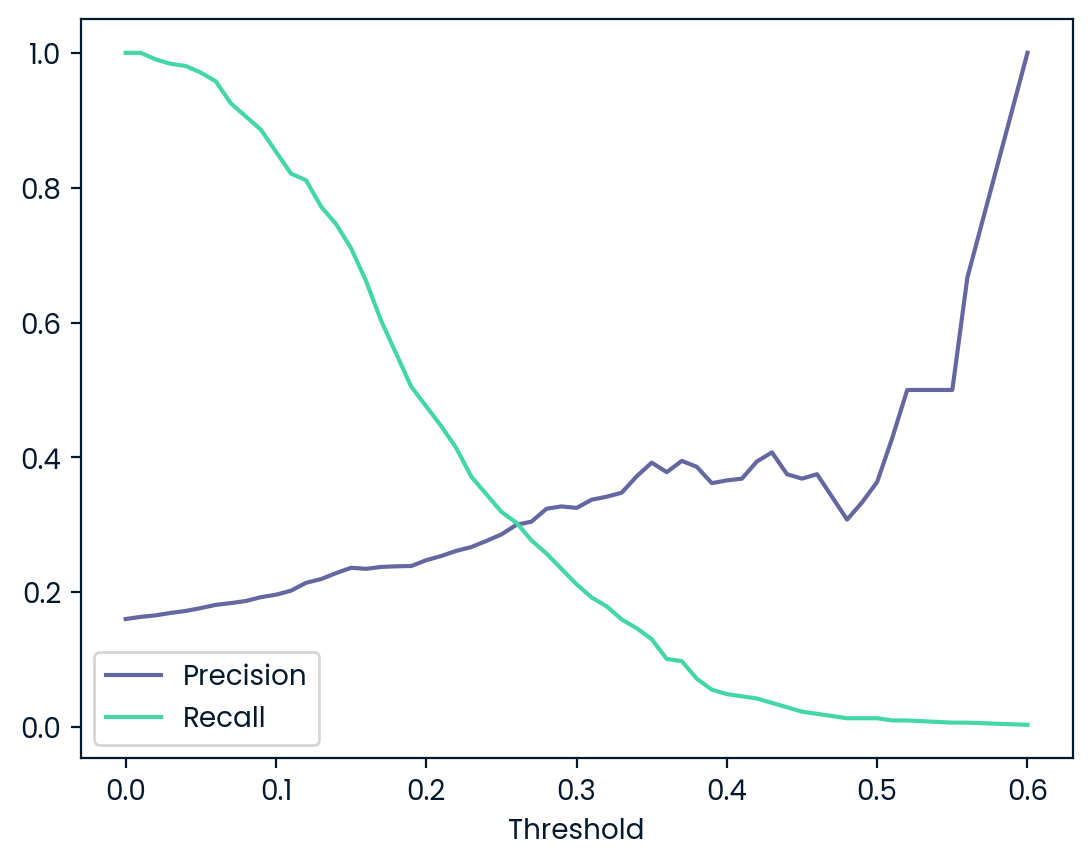

In [26]:
### 7. Model Evaluation

#### 7.1. Metrics

# - Accuracy is not enough due to class imbalance.
# - Use confusion matrix, precision, recall, F1-score, and ROC-AUC.
# - Focus on recall for the "not fully paid" class (minimize false negatives).

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))

#### 7.2. Adjusting Threshold

# - Adjust the probability threshold to increase recall for "not fully paid" loans.

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = clf.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot precision-recall curve
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

## 8. Findings & Conclusions

### Confusion Matrix Analysis

The confusion matrix output:

$$
\begin{bmatrix}
1605 & 4 \\
304 & 3 \\
\end{bmatrix}
$$

- **True Negatives (TN):** 1605 — Loans correctly predicted as fully paid.
- **False Positives (FP):** 4 — Loans incorrectly predicted as not fully paid (but were actually fully paid).
- **False Negatives (FN):** 304 — Loans incorrectly predicted as fully paid (but were actually not fully paid).
- **True Positives (TP):** 3 — Loans correctly predicted as not fully paid.

### Key Findings

- **Recall for Not Fully Paid Loans (Class 1):**
  - The recall is very low ($0.01$), meaning the model only identified 3 out of 307 actual risky loans. This results in a high number of false negatives (304), which is problematic for risk management.
- **Precision for Not Fully Paid Loans:**
  - The precision is $0.43$, indicating that when the model predicts a loan as risky, it is correct 43% of the time. However, this is based on very few positive predictions.
- **Overall Accuracy:**
  - The model achieves an accuracy of $0.84$, but this is misleading due to class imbalance. Most loans are fully paid, so predicting the majority class yields high accuracy.
- **ROC-AUC:**
  - The ROC-AUC score of $0.67$ suggests the model has some ability to distinguish between classes, but performance is moderate.

### Conclusions

- **Class Imbalance Remains a Challenge:**
  - Despite using class weights, the model struggles to identify the minority class (not fully paid loans), as shown by the low recall.
- **Business Impact:**
  - The high number of false negatives means many risky loans are not being flagged, which could lead to financial losses.
- **Key Correlations:**
  - Higher interest rates, lower FICO scores, and higher debt-to-income ratios are associated with increased risk, as previously identified.
- **Next Steps:**
  - Further work is needed to improve recall for the minority class, such as advanced resampling techniques, hyperparameter tuning, or alternative models.
  - Deploying the model should be accompanied by ongoing monitoring and adjustment to ensure real-world effectiveness.

**In summary:** While the model performs well for the majority class, its ability to detect risky loans is limited. Improving recall for the minority class is essential for maximizing business value and minimizing risk.